The Census offers a wealth of data that can be used to understand the demographics and socio-economic characteristics of different areas. The data is made available at a variety of geographic levels. We will explore the impact of using different geographic levels to explore phenomena, and compare the shape of the data and how different representation strategies can have a meaningful impact on how we understand the data.

We will then turn to using different variables to explore a 2017 New York City Council local law that required the City to determine a baseline understanding of environmental justice as a precursor to developing strategies to respond to environmental injustice. The City Council proposed two initial measures, income and minority status, as the basis for defining environmental justice areas. While this definition was later superseded in favor of New York States' definition, the definitions provide a case study for classifying census variables to help us develop categories of environmental justice areas.

In [68]:
import geopandas as gpd
import numpy as np
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, PuRd_9, YlGn_9
from matplotlib.patches import Patch

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [69]:
census_data = gpd.read_file("./Data/census_nyc_sp.fgb")

In [70]:
census_data.head()

,GISJOIN,Total Pop (Race/Ethnicity),Not Hispanic or Latino,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some other race alone,Not Hispanic or Latino: Two or more races,...,"$75,000 to $99,999","$100,000 to $124,999","$125,000 to $149,999","$150,000 to $199,999","$200,000 or more",COUNTY,TRACTCE,BLKGRPCE,Area (Sq Mi),geometry
0,G36008101010021,3837,3817,3817,0,0,0,0,0,0,...,75,94,30,164,276,Queens County,101002,1,0.157620,"MULTIPOLYGON (((1056895.943 157320.531, 105674..."
1,G36008101010022,2275,1803,648,350,0,794,0,0,11,...,48,88,0,0,204,Queens County,101002,2,0.048883,"MULTIPOLYGON (((1057018.771 155993.29, 1056995..."
2,G36008101010043,2123,1506,487,766,0,243,0,0,10,...,55,58,0,41,28,Queens County,101004,3,0.039452,"MULTIPOLYGON (((1055223.035 157038.704, 105528..."
3,G36008101010042,1464,1342,576,718,0,9,0,0,39,...,245,0,0,0,0,Queens County,101004,2,0.054139,"MULTIPOLYGON (((1055223.035 157038.704, 105498..."
4,G36008101010032,467,195,90,76,0,12,0,0,17,...,0,0,0,26,0,Queens County,101003,2,0.013168,"MULTIPOLYGON (((1054329.195 158352.062, 105414..."


<Axes: >

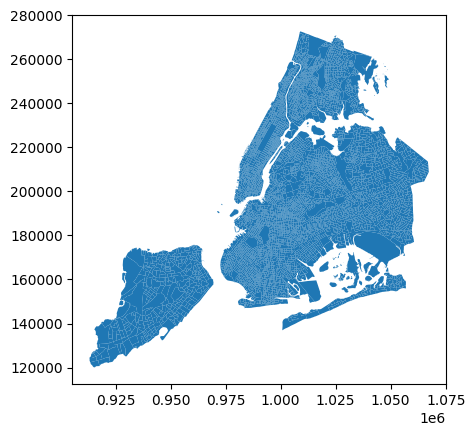

In [71]:
census_data.plot()

We can plot the **total population** per block group by selecting that column in our data frame and passing it to the `column` argument of the `plot` method. This will create a choropleth map where the color of each block group corresponds to its total population.

<Axes: >

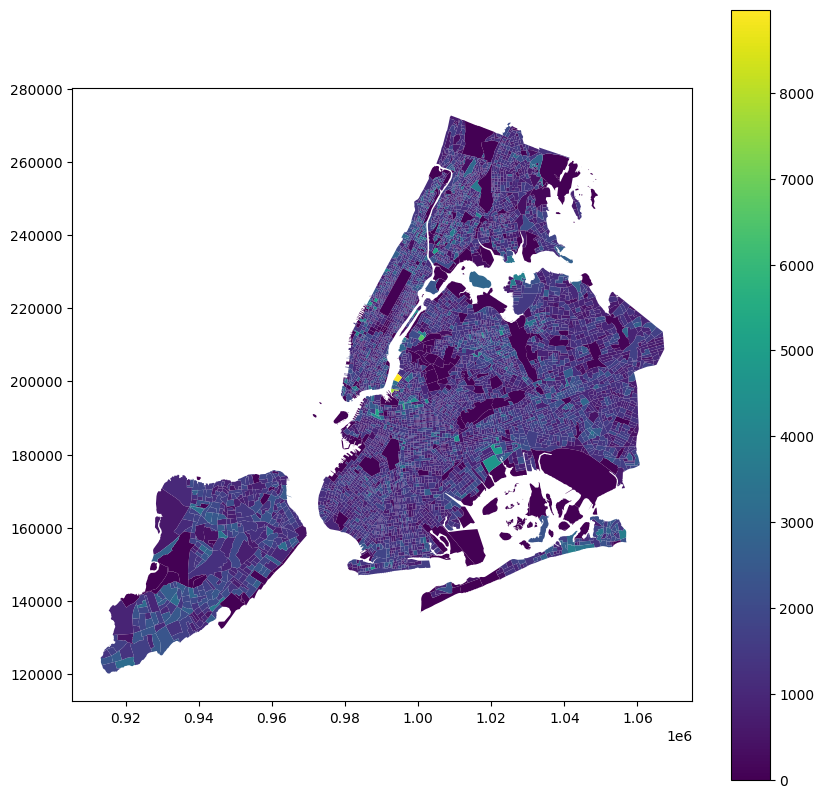

In [72]:
census_data.plot(
    column="Total Pop (Race/Ethnicity)",
    figsize=(10, 10),
    legend=True,
)

Our first mapping of a variable! However, it doesn't reveal much- you may or may not be able to spot block groups from each of the breaks in the legend. Let's take a look at the distribution of the population variable to understand why this is the case.

In [73]:
census_data["Total Pop (Race/Ethnicity)"].describe()

count    6593.000000
mean     1286.795692
std       684.693325
min         0.000000
25%       842.000000
50%      1202.000000
75%      1643.000000
max      8974.000000
Name: Total Pop (Race/Ethnicity), dtype: float64

<Axes: >

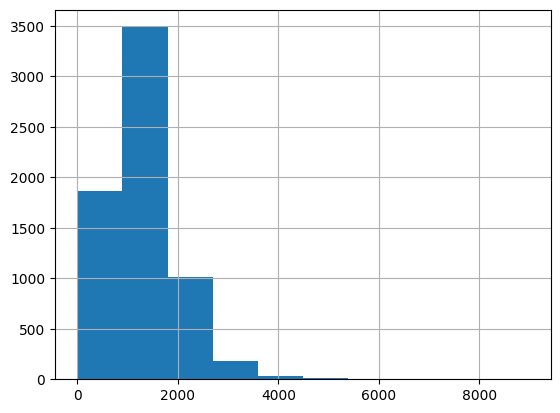

In [74]:
census_data["Total Pop (Race/Ethnicity)"].hist()

Based on the `describe()` and `hist()` outputs, we can see that the population variable is highly skewed, with a few block groups having very high populations and many block groups having low populations. We can use different classification methods to draw out these relationships more clearly.

<Axes: >

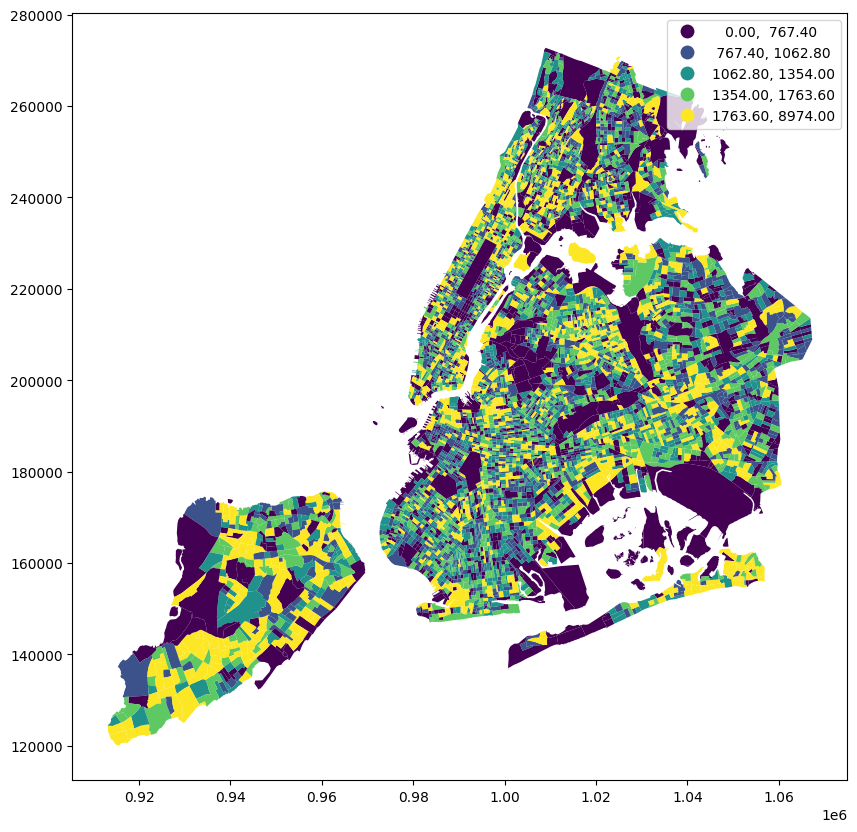

In [75]:
census_data.plot(
    column="Total Pop (Race/Ethnicity)",
    figsize=(10, 10),
    legend=True,
    scheme="quantiles",
)

Now we have a very different map! We're using quantiles to break the population variable into 5 classes, so each class has the same number of block groups. This allows us to understand the variation better to a degree, but still has an issue- we are looking at *population* and not *population density*. The block groups with the highest population are not necessarily the most densely populated, and vice versa. Let's take a look at the population density variable to see how it compares to the population variable.

In [76]:
census_data["pop_density"] = (
    census_data["Total Pop (Race/Ethnicity)"] / census_data["Area (Sq Mi)"]
)

Now that we have our normalized population variable, let's take a look at how it compares to the population variable.

<Axes: >

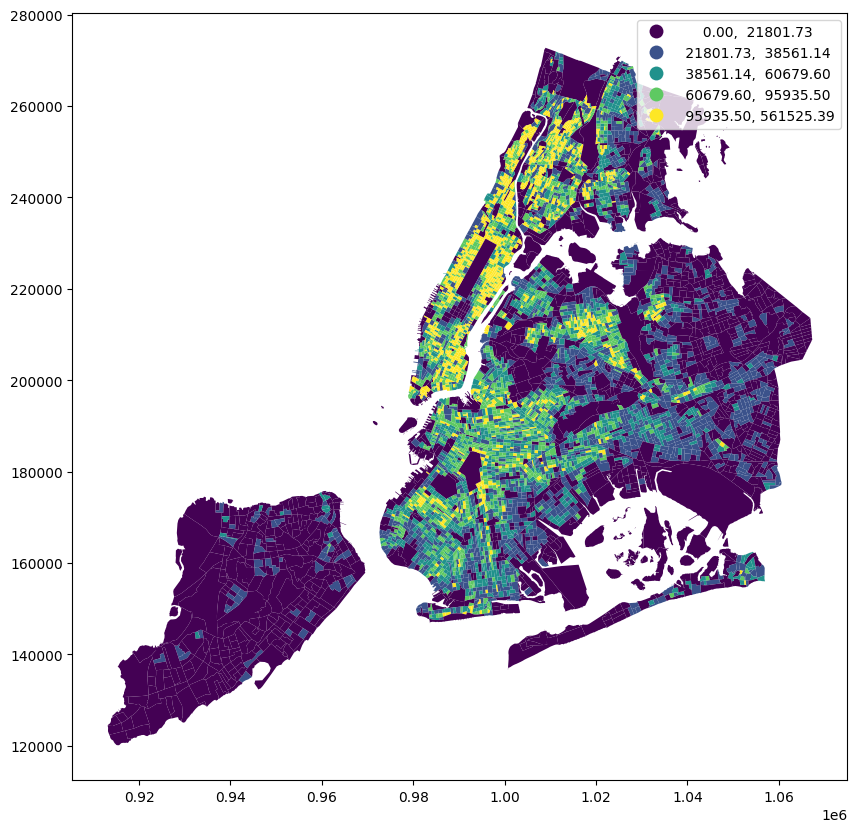

In [77]:
census_data.plot(
    column="pop_density", figsize=(10, 10), legend=True, scheme="quantiles"
)

A much different pattern emerges. We can see high-density block groups in Manhattan, the Bronx, Brooklyn, and parts of Queens, while eastern Queens and Staten Island are comparatively very low density. 

You may also notice that the low threshold for the first category is 0, which means there are block groups with no population. Let's separate those areas out so that we can separate the unpopulated areas from the low population areas. We can use filter statements to do so.

<Axes: >

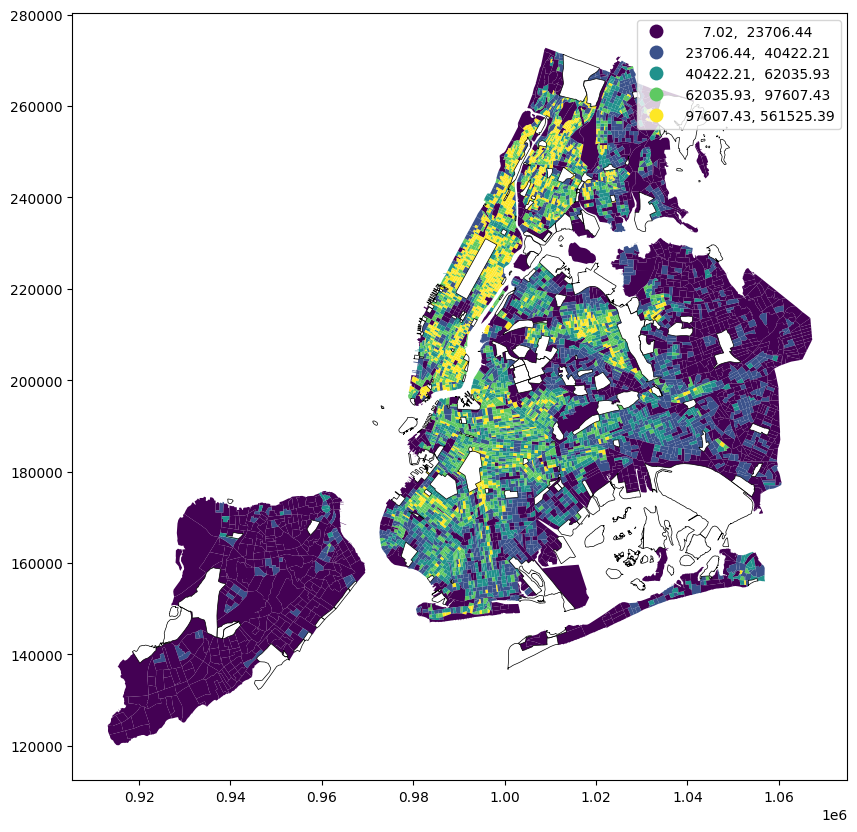

In [78]:
ax = census_data[census_data["pop_density"].gt(0)].plot(
    column="pop_density", figsize=(10, 10), legend=True, scheme="quantiles"
)

census_data[census_data["pop_density"].eq(0)].boundary.plot(
    ax=ax, color="black", linewidth=0.5, label="0 pop density"
)

In [79]:
pop_density = census_data["pop_density"].to_numpy()
pop_density = np.nan_to_num(pop_density, nan=0)

scaled_pop_density = pop_density / pop_density.max() * 10000

normalizer = LogNorm(1, scaled_pop_density.max(), clip=True)
normalized_pop_density = normalizer(scaled_pop_density)

colors = apply_continuous_cmap(normalized_pop_density, Oranges_9)

In [80]:
layer = PolygonLayer.from_geopandas(
    gdf=census_data[
        [
            "GISJOIN",
            "pop_density",
            "geometry",
        ]
    ],
    extruded=True,
    get_elevation=scaled_pop_density,
    get_fill_color=colors,
    wireframe=True,
)

/Users/marioag/miniforge3/envs/cdp26/lib/python3.14/site-packages/lonboard/_geoarrow/ops/reproject.py:116: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


In [81]:
view_state = {
    "longitude": -73.98416810282863,
    "latitude": 40.72651721370669,
    "zoom": 9.2,
    "pitch": 59.80465353190481,
    "bearing": 13.243243243243244,
}
m = Map(layer, view_state=view_state)
m

In [82]:
census_tract_data = census_data.dissolve(
    by="TRACTCE",
    aggfunc={
        "Total Pop (Race/Ethnicity)": "sum",
        "Area (Sq Mi)": "sum",
    },
)

In [83]:
census_tract_data["pop_density"] = (
    census_tract_data["Total Pop (Race/Ethnicity)"] / census_tract_data["Area (Sq Mi)"]
)

<Axes: >

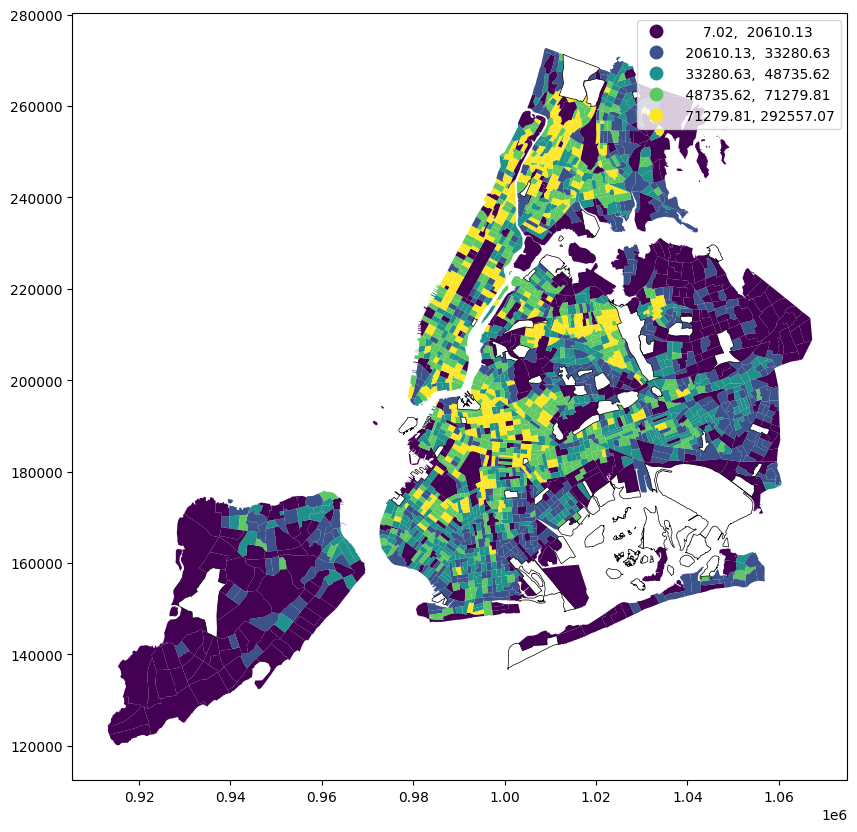

In [84]:
ax = census_tract_data[census_tract_data["pop_density"].gt(0)].plot(
    column="pop_density", figsize=(10, 10), legend=True, scheme="quantiles"
)

census_tract_data[census_tract_data["pop_density"].eq(0)].boundary.plot(
    ax=ax, color="black", linewidth=0.5, label="0 pop density"
)

<Axes: >

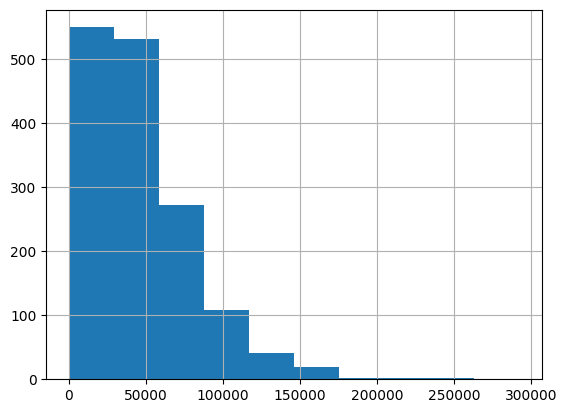

In [85]:
census_tract_data["pop_density"].hist()

<Axes: >

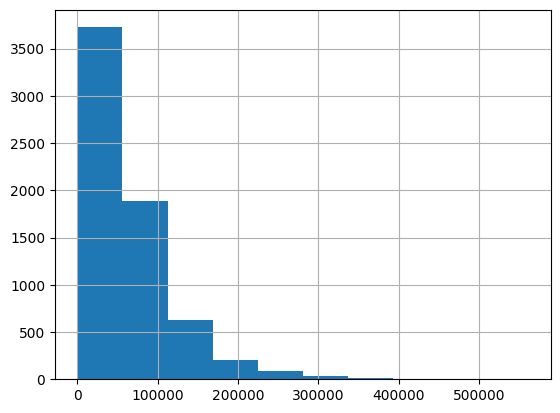

In [86]:
census_data["pop_density"].hist()

In [87]:
pop_density_tract = census_tract_data["pop_density"].to_numpy()
pop_density_tract = np.nan_to_num(pop_density_tract, nan=0)

scaled_pop_density_tract = (
    pop_density_tract / pop_density.max() * 10000
)  # keep to same scale as census block group data

normalizer = LogNorm(1, scaled_pop_density_tract.max(), clip=True)
normalized_pop_density_tract = normalizer(scaled_pop_density_tract)

colors_tract = apply_continuous_cmap(normalized_pop_density_tract, YlGn_9)

In [88]:
layer = PolygonLayer.from_geopandas(
    gdf=census_data[
        [
            "GISJOIN",
            "pop_density",
            "geometry",
        ]
    ],
    extruded=True,
    get_elevation=scaled_pop_density,
    get_fill_color=colors,
    wireframe=True,
    opacity=0.5,
)

/Users/marioag/miniforge3/envs/cdp26/lib/python3.14/site-packages/lonboard/_geoarrow/ops/reproject.py:116: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


In [89]:
layer_tract = PolygonLayer.from_geopandas(
    gdf=census_tract_data[
        [
            "pop_density",
            "geometry",
        ]
    ],
    extruded=True,
    get_elevation=scaled_pop_density_tract,
    get_fill_color=colors_tract,
    opacity=0.75,
    wireframe=True,
)

/Users/marioag/miniforge3/envs/cdp26/lib/python3.14/site-packages/lonboard/_geoarrow/ops/reproject.py:116: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


In [90]:
m = Map([layer, layer_tract], view_state=view_state)
m

In [91]:
census_data.columns

Index(['GISJOIN', 'Total Pop (Race/Ethnicity)', 'Not Hispanic or Latino',
       'Not Hispanic or Latino: White alone',
       'Not Hispanic or Latino: Black or African American alone',
       'Not Hispanic or Latino: American Indian and Alaska Native alone',
       'Not Hispanic or Latino: Asian alone',
       'Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone',
       'Not Hispanic or Latino: Some other race alone',
       'Not Hispanic or Latino: Two or more races',
       'Not Hispanic or Latino: Two or more races: Two races including Some other race',
       'Not Hispanic or Latino: Two or more races: Two races excluding Some other race, and three or more races',
       'Hispanic or Latino', 'Total Households (Income)', 'Less than $10,000',
       '$10,000 to $14,999', '$15,000 to $19,999', '$20,000 to $24,999',
       '$25,000 to $29,999', '$30,000 to $34,999', '$35,000 to $39,999',
       '$40,000 to $44,999', '$45,000 to $49,999', '$50,000 to $59,999',
  

In [92]:
hh_income_columns = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $19,999",
    "$20,000 to $24,999",
    "$25,000 to $29,999",
    "$30,000 to $34,999",
    "$35,000 to $39,999",
    "$40,000 to $44,999",
    "$45,000 to $49,999",
    "$50,000 to $59,999",
    "$60,000 to $74,999",
    "$75,000 to $99,999",
    "$100,000 to $124,999",
    "$125,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more",
]

In [93]:
census_data_income = census_data[
    [
        "GISJOIN",
        "Less than $10,000",
        "$10,000 to $14,999",
        "$15,000 to $19,999",
        "$20,000 to $24,999",
        "$25,000 to $29,999",
        "$30,000 to $34,999",
        "$35,000 to $39,999",
        "$40,000 to $44,999",
        "$45,000 to $49,999",
        "$50,000 to $59,999",
        "$60,000 to $74,999",
        "$75,000 to $99,999",
        "$100,000 to $124,999",
        "$125,000 to $149,999",
        "$150,000 to $199,999",
        "$200,000 or more",
        "geometry",
    ]
].copy()

In [94]:
hh_income_cols = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $19,999",
    "$20,000 to $24,999",
    "$25,000 to $29,999",
    "$30,000 to $34,999",
    "$35,000 to $39,999",
    "$40,000 to $44,999",
    "$45,000 to $49,999",
    "$50,000 to $59,999",
    "$60,000 to $74,999",
    "$75,000 to $99,999",
    "$100,000 to $124,999",
    "$125,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more",
]


def qualify_ej_poverty(r, thresh=0.2359, qual_cols=[], all_inc_cols=[]):
    """
    Determines if a row qualifies as an environmental justice (EJ) area based on poverty criteria,
    If the share of the row households in the poverty category (or categories) specified in qual_cols
    exceeds the threshold, then the row is classified as an EJ area.
    """
    total_hh = r[all_inc_cols].sum()
    if total_hh == 0:
        return None
    poverty_hh = r[qual_cols].sum()
    poverty_share = poverty_hh / total_hh
    return poverty_share > thresh

In [95]:
census_data["is_ej_poverty"] = census_data.apply(
    lambda row: qualify_ej_poverty(
        row,
        thresh=0.2359,
        qual_cols=hh_income_columns[
            :4
        ],  # assumes a household of 3 or more in poverty if income is less than $25,000
        all_inc_cols=hh_income_columns,
    ),
    axis=1,
)

<Axes: >

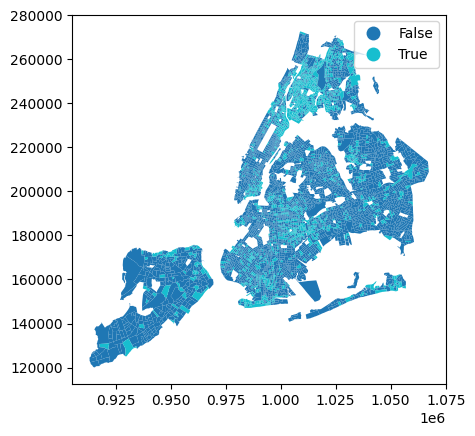

In [96]:
census_data.plot("is_ej_poverty", legend=True)

In [97]:
def qualify_ej_minority(r, thresh=0.511):
    """
    Determines if a row qualifies as an environmental justice (EJ) area based on minority population criteria.
    If the share of the row population that is non-white exceeds the threshold, then the row is classified as an EJ area.
    """
    total_pop = r["Total Pop (Race/Ethnicity)"]
    if total_pop == 0:
        return None
    non_white_pop = total_pop - r["Not Hispanic or Latino: White alone"]
    non_white_share = non_white_pop / total_pop
    return non_white_share > thresh

In [98]:
census_data["is_ej_minority"] = census_data.apply(
    lambda row: qualify_ej_minority(row, thresh=0.511), axis=1
)

<Axes: >

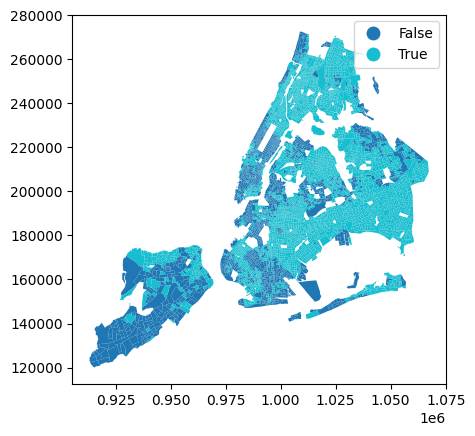

In [99]:
census_data.plot("is_ej_minority", legend=True)

In [100]:
def qualify_ej(r):
    """if either poverty or minority criteria are met, then row is classified as EJ area"""
    return qualify_ej_minority(r) or qualify_ej_poverty(r)

In [101]:
census_data["is_ej_area"] = census_data.apply(qualify_ej, axis=1)

<Axes: >

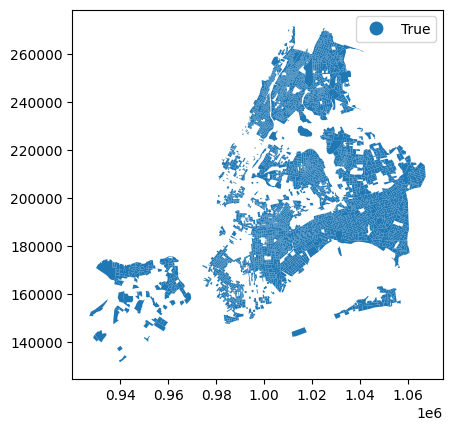

In [102]:
census_data.plot("is_ej_area", legend=True)

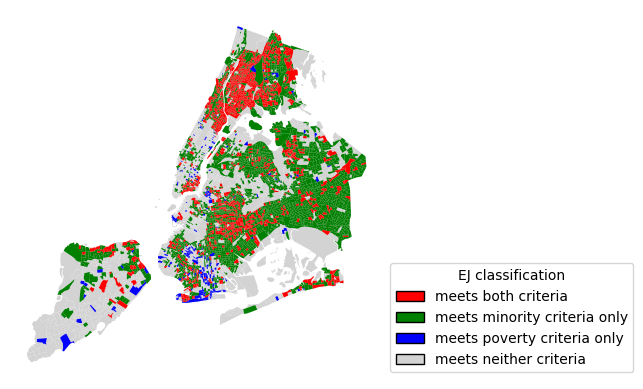

In [108]:
is_minority = census_data["is_ej_minority"].fillna(False)
is_poverty = census_data["is_ej_poverty"].fillna(False)

mask_both = is_minority & is_poverty
mask_minority_only = is_minority & ~is_poverty
mask_poverty_only = ~is_minority & is_poverty
mask_neither = ~is_minority & ~is_poverty

# Plot base first so highlighted classes draw on top
ax = census_data[mask_neither].plot(color="lightgrey", linewidth=0.5)
census_data[mask_poverty_only].plot(ax=ax, color="blue", linewidth=0.5)
census_data[mask_minority_only].plot(ax=ax, color="green", linewidth=0.5)
census_data[mask_both].plot(ax=ax, color="red", linewidth=0.5).set_axis_off()

legend_handles = [
    Patch(facecolor="red", edgecolor="black", label="meets both criteria"),
    Patch(facecolor="green", edgecolor="black", label="meets minority criteria only"),
    Patch(facecolor="blue", edgecolor="black", label="meets poverty criteria only"),
    Patch(facecolor="lightgrey", edgecolor="black", label="meets neither criteria"),
]

ax.legend(
    handles=legend_handles,
    title="EJ classification",
    loc="lower left",
    bbox_to_anchor=(1, 0),
)